In [27]:
import os

for dir_path,dir_names,file_names in os.walk("new_data"):
    print(f"There are {len(dir_names)} directories in {len(file_names)} images in {dir_path}")

There are 2 directories in 0 images in new_data
There are 3 directories in 0 images in new_data\test
There are 0 directories in 45 images in new_data\test\rajan
There are 0 directories in 45 images in new_data\test\raka
There are 0 directories in 45 images in new_data\test\shuvam
There are 3 directories in 0 images in new_data\train
There are 0 directories in 1155 images in new_data\train\rajan
There are 0 directories in 1155 images in new_data\train\raka
There are 0 directories in 1154 images in new_data\train\shuvam


In [28]:
# Setup the train and test directories
from pathlib import Path
base_dir = Path.cwd()
train_dir = base_dir / "new_data" / "train"
test_dir = base_dir / "new_data" / "test"


In [29]:
# Lets get the class names
import pathlib
import numpy as np
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name.strip() for item in data_dir.glob('*')]))
print(class_names)

['rajan' 'raka' 'shuvam']


In [30]:
# Creating a function
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir,target_class):
    target_folder = Path(target_dir) / str(target_class)
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)

    img_path = target_folder / random_image[0]
    img = mpimg.imread(str(img_path))
    plt.imshow(img)
    plt.title(str(target_class))
    plt.axis("off")

    print(f"Image shape: {img.shape}")

    return img

['rajan_1 (866).jpg']
Image shape: (480, 640, 3)


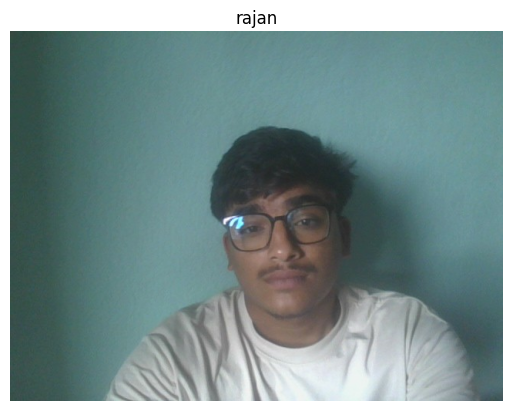

In [31]:
# visualize
import os
import random
from pathlib import Path
img = view_random_image(target_dir=Path(train_dir), target_class=str(random.choice(class_names)))

In [32]:
import pandas as pd
def plot_loss_curves(history):
    loss=history.history["loss"]
    accuracy=history.history["accuracy"]
    val_accuracy=history.history["val_accuracy"]
    val_loss=history.history["val_loss"]

    epochs = range(len(history.history["loss"]))
    #Plot loss
    plt.plot(epochs, loss, label="training loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("loss")
    plt.xlabel("epochs")
    plt.legend()

    #Plot accuracy
    plt.figure()
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("accuracy")
    plt.xlabel("epochs")
    plt.legend()

In [33]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# -------------------------------
# Paths
# -------------------------------
# train_dir = "data/train"
# test_dir = "data/test"

# -------------------------------
# Image Data Generators
# -------------------------------
# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1  # 10% of training data for validation
)

# Test data: only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# -------------------------------
# Generators
# -------------------------------
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",  # this is training split
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",  # this is validation split
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# -------------------------------
# Model (stronger CNN)
# -------------------------------
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation="relu", input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),  # reduce overfitting
    tf.keras.layers.Dense(3, activation="softmax")  # 3 classes
])

model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    metrics=["accuracy"]
)

# -------------------------------
# Train
# -------------------------------
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=20
)

Found 3119 images belonging to 3 classes.
Found 345 images belonging to 3 classes.
Found 135 images belonging to 3 classes.
Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 57s 565ms/step - accuracy: 0.3825 - loss: 1.0823 - val_accuracy: 0.5478 - val_loss: 1.0809
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 59s 602ms/step - accuracy: 0.4588 - loss: 1.0553 - val_accuracy: 0.5362 - val_loss: 1.0695
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 54s 550ms/step - accuracy: 0.5406 - loss: 1.0298 - val_accuracy: 0.5507 - val_loss: 1.0576
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 54s 547ms/step - accuracy: 0.5595 - loss: 1.0080 - val_accuracy: 0.5594 - val_loss: 1.0428
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 55s 564ms/step - accuracy: 0.6005 - loss: 0.9763 - val_accuracy: 0.5217 - val_loss: 1.0269
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 54s 548ms/step - accuracy: 0.6028 - loss: 0.9584 - val_accuracy: 0.5043 - val_loss: 1.0092
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 53s 540ms/step - accuracy: 0.6236 - loss: 0.9329 - val_accuracy:

In [34]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,508,043 (127.82 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,696 (85.22 MB)

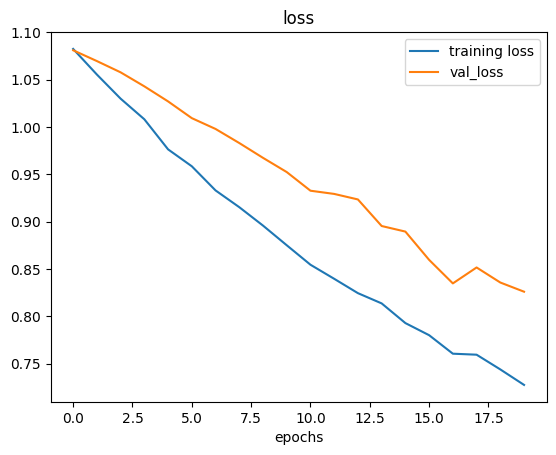

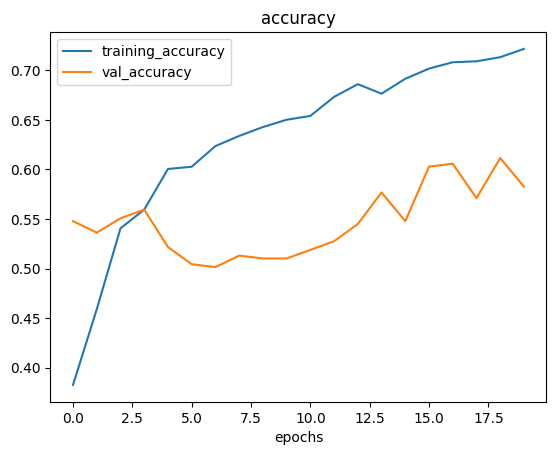

In [35]:
plot_loss_curves(history)

In [36]:
def load_and_prep_image(filename, img_shape=224):
    """
    Reads an image from filename, turns it into a tensor and reshapes it
    to (img_shape, img_shape, colour_channels).
    """
    # Read in the image
    img = tf.io.read_file(filename)
    # Decode the read file into a tensor
    img = tf.image.decode_image(img)
    # Resize the image
    img = tf.image.resize(img, size=[img_shape, img_shape])
    # Rescale the image (get all values between 0 and 1)
    img = img/255.
    return img

In [37]:
def pred_and_plot(model, filename, class_names=class_names):
    """
    Imports an image located at filename, makes a prediction with model
    and plots the image with the predicted class as the title.
    """
    # Import the target image and preprocess it
    img = load_and_prep_image(filename)

    # Make a prediction
    pred = model.predict(tf.expand_dims(img, axis=0))

    #Add logic for multiclass
    if len(pred[0]) > 1:
        pred_class = class_names[tf.argmax(pred[0])]
    else:
        # Get the predicted class
        pred_class = class_names[int(tf.round(pred[0]))]
    # Plot the image and predicted class
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


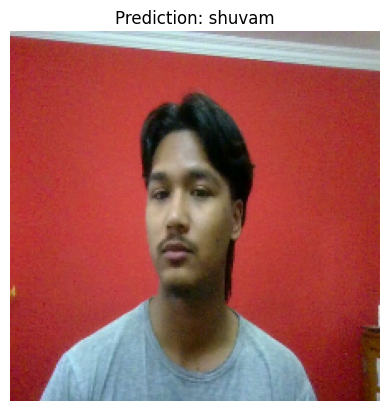

In [38]:

# Test on RAKA
pred_and_plot(model, "new_data/test/raka/raka_1 (1).jpg", class_names=class_names)

# Test on RAJAN
pred_and_plot(model, "new_data/test/rajan/rajan_1 (1).jpg", class_names=class_names)

# Test on SHUVAM
pred_and_plot(model, "new_data/test/shuvam/shuvam_1 (1).jpg", class_names=class_names)

In [39]:
import os
# Make sure the folder exists outside the current 'model' folder
os.makedirs('../final_model', exist_ok=True)

# Save the model in that folder
model.save('../final_model/FRAME.h5')